<div style="font-weight: bold; color:#5D8AA8" align="center">
    <div style="font-size: xx-large">Métodos Funcionales en Aprendizaje Automático</div><br>
    <div style="font-size: x-large; color:gray">Homework 03 - Diffusion Maps</div><br>
    <div style="font-size: large">Authors</div><br>Sergio Fernández Munguía e Iñigo Martínez Ciriza</div><hr>
</div>

**Initial Configuration**

This cell defines the configuration of Jupyter Notebooks.

In [1]:
%%html
<style>
    .qst {background-color: #b1cee3; padding:10px; border-radius: 5px; border: solid 2px #5D8AA8;}
    .qst:before {font-weight: bold; content:"Exercise"; display: block; margin: 0px 10px 10px 10px;}
    h1, h2, h3 {color: #5D8AA8;}
    .text_cell_render p {text-align: justify; text-justify: inter-word;}
</style>

In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

This cell imports the packages to be used.

In [3]:
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
from itertools import product
from sklearn.datasets import make_blobs, make_swiss_roll, make_s_curve
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.utils.extmath import svd_flip
from mpl_toolkits.mplot3d import Axes3D
Axes3D

matplotlib.rc('figure', figsize=(15, 5))

seed = 123
my_cmap = plt.cm.Spectral

# Introduction

This practical assignment is about implementing the manifold learning method **Diffusion Maps**, following the *scikit-learn* template for manifold learning algorithms.

We will design two main functions: one for training the algorithm, obtaining the affinity matrix and the embedded coordinates, and a second one for extending these coordinates for new patterns.

# Requirements

The objective of this assignment is to complete the class DM sketched below, which should contain at least the following methods.

`__init__(self, sigma, n_components, step=1, alpha=1)`

* This is the construction method for the class, with the following parameters:
    * `sigma`: Kernel parameter for the Gaussian kernel.
    * `n_components`: dimension of the embedding.
    * `step`: step in the Markov Chain.
    * `alpha`: density influence. It should take a value in `[0,1]`.
* This method just store the parameters in the fields of the class, to be used when needed.

`fit(self, X, y=None)`

* This is the training method, the one that performs the Diffusion Maps algorithm. 

* This method should store the affinity matrix and also the eigenvectors to computed the transformation.

`fit_transform(self, X, y=None)`

* This method returns the embedding coordinates for the training data.
* It should also store the affinity matrix and the coordinates needed to compute the transformation (for example over new, unseen patterns).

`transform(self, X)`

* This method will obtain approximated coordinates for new, unseen data points. 
* It uses for this purpose the Nyström Formula.

## Some recommendations

* It should allow to fix all the DM possibilities (different steps, density normalization...). To allow a change in the kernel function could be also a nice idea.
* Implement all the auxiliary functions that you may need, for example, for deciding the best parameter values in each case.
* It could be a nice idea to offer a deterministic output, that do not depend on the sign of the eigenvectors.

# Implementation

<div class="qst">

* Complete the `DM` class below, satisfying the described requirements.

</div>

In [4]:
from sklearn.base import BaseEstimator, TransformerMixin

class DM(TransformerMixin, BaseEstimator):
    """
        Diffusion Maps.
    """
    def __init__(self, sigma, n_components, alpha, step=1):
        # Assignment of the hyper-parameters
        self.sigma = sigma
        self.n_components = n_components
        self.step = step
        self.alpha = alpha

    def fit(self, X, y=None):
        """Compute the embedding vectors for data X
        Parameters
        ----------
        X : array-like of shape [n_samples, n_features]
            training set.
        y : Ignored
        Returns
        -------
        self : returns an instance of self.
        """
        self.X = X

        # Gaussian kernel
        pairwise_dists = pairwise_distances(X, X, squared=True)
        K = np.exp(-pairwise_dists / (2 * self.sigma**2))
        self.affinity_matrix = K
        
        # Degree of each node kernel (save them for tranform)
        D = np.sum(K, axis=1)**self.alpha
        
        # Normalized kernel
        K_alpha = K / D / D.T
        
        # Degree of each node of normalized kernel
        D_alpha = np.sum(K_alpha, axis=1).reshape(-1, 1)
        
        # Compute the probability matrix
        P = K_alpha / D_alpha

        # Compute the stationary distribution
        pi = (D / np.sum(D)).reshape(-1, 1)
        
        # Compute the A matrix
        D_sqrt = np.sqrt(D)
        A = K / np.outer(D_sqrt, D_sqrt)

        # SVD decomposition
        eigenvectors, eigenvalues, V = np.linalg.svd(A)
        
        # Flip the eigenvectors sign to ensure deterministic output from SVD
        eigenvectors, _ = svd_flip(eigenvectors, V)
        
        # Normalize eigenvectors
        eigenvectors = eigenvectors / np.sqrt(pi)
        
        # Save the eigenvalues and eigenvectors
        self.lambdas_ = eigenvalues[1:self.n_components + 1]
        self.psi_ = eigenvectors[:, 1:self.n_components +1]      
        return self
    
    def fit_transform(self, X, y=None):
        """Compute the embedding vectors for data X and transform X.
        Parameters
        ----------
        X : array-like of shape [n_samples, n_features]
            training set.
        y : Ignored
        Returns
        -------
        X_red : array-like, shape (n_samples, n_components)
        """
        self.fit(X)
        embedding_ = self.psi_ * (self.lambdas_ ** self.step)
        
        return embedding_
    
    def transform(self, Y):
        """Transform Y.
        This function is implemented using the Nyström formula.
        Parameters
        ----------
        Y : array-like, shape (n_samples, n_features).
        Returns
        -------
        Y_red : array-like, shape (n_samples, n_components)
        """
        # Gaussian kernel between new points and training data
        cross_dists = pairwise_distances(Y, self.X, squared=True)
        K_crossed = np.exp(-cross_dists / (2 * self.sigma**2))
        
        y_dists = pairwise_distances(Y, Y, squared=True)
        K_y = np.exp(-y_dists / (2 * self.sigma**2))
        
        # Build extended affinity matrix
        K_prime = np.hstack([
            np.vstack([self.affinity_matrix, K_crossed]),
            np.vstack([K_crossed.T, K_y])
        ])
        
        # Apply density normalization to extended matrix
        D_prime = np.sum(K_prime, axis=1)**self.alpha
        K_prime_alpha = K_prime / np.outer(D_prime, D_prime) 
        
        # Compute extended probability matrix
        D_prime_alpha = np.sum(K_prime_alpha, axis=1).reshape(-1, 1)
        P_prime = K_prime_alpha / D_prime_alpha
        
        # Extract P(Y, X) block
        P_cross = P_prime[len(self.X):, :len(self.X)]

        # Nyström formula
        Y_red = np.array([
            (P_cross @ v.T) / lamb
            for v, lamb in zip(self.psi_.T, self.lambdas_)
        ]).T
        
        return Y_red

In [5]:
from itertools import product

def plot_diffusion_embeddings(X_train, c_train, X_new, c_new, param_grid,
                                                 n_rows_per_fig=3, figsize=(15, 10)):
    """
    Visualize Diffusion Maps embeddings for different parameter combinations,
    splitting the plots into multiple figures (each with n_rows_per_fig rows) to better display them.

    Parameters:
    - X_train: Training data (numpy array)
    - c_train: Color values/labels for training data
    - X_new: New data to project
    - c_new: Color values/labels for new data
    - param_grid: Dictionary of parameter lists to test (e.g., {'sigma': [...], 'alpha': [...], 'step': [...]})
    - n_rows_per_fig: Number of parameter combinations to show per figure
    - figsize: Figure dimensions for each figure
    """
    param_combos = list(product(*param_grid.values()))
    n_total = len(param_combos)
    
    for i in range(0, n_total, n_rows_per_fig):
        batch = param_combos[i:i+n_rows_per_fig]
        n_rows = len(batch)
        
        _, axs = plt.subplots(n_rows, 2, figsize=figsize)
        if n_rows == 1:
            axs = np.expand_dims(axs, axis=0)
            
        plt.subplots_adjust(hspace=0.5, wspace=0.3)
        
        for row_idx, (sigma, alpha, step) in enumerate(batch):
            dm = DM(sigma=sigma, alpha=alpha, step=step, n_components=2)
            train_emb = dm.fit_transform(X_train)
            new_emb = dm.transform(X_new)
            
            axs[row_idx, 0].scatter(train_emb[:, 0], train_emb[:, 1],
                                    c=c_train, cmap=my_cmap)
            axs[row_idx, 0].set_title(f"Train\n$\\sigma$={sigma}, $\\alpha$={alpha}, t={step}", fontsize=10)
            
            axs[row_idx, 1].scatter(new_emb[:, 0], new_emb[:, 1],
                                    c=c_new, cmap=my_cmap, marker='X')
            axs[row_idx, 1].set_title(f"New\n$\\sigma$={sigma}, $\\alpha$={alpha}, t={step}", fontsize=10)
        
        plt.show()

# Experiments with DM

<div class="qst">

* Obtain some good embedded coordinates for the three training datasets specified below.
    
* Extend its coordinates for the new points.
    
</div>

## Dataset 1: two blobs

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

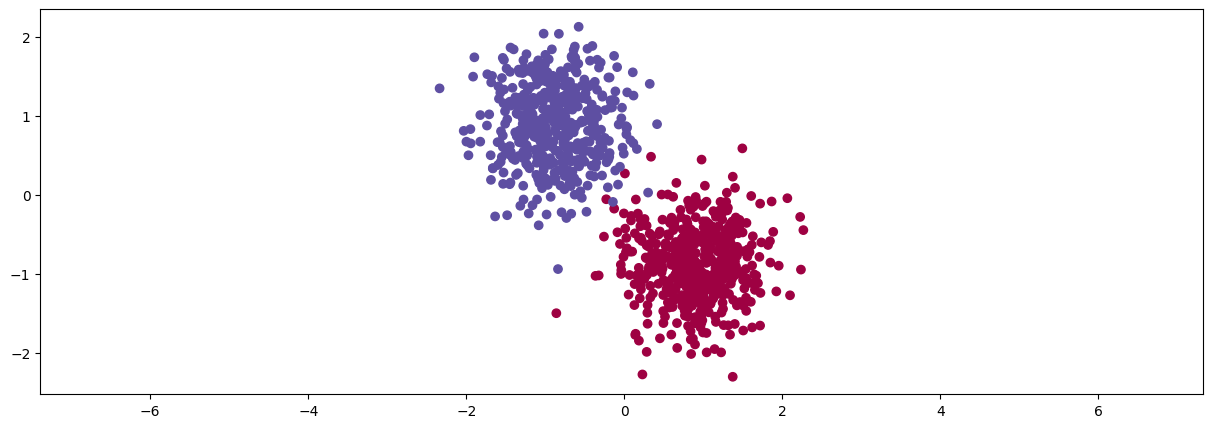

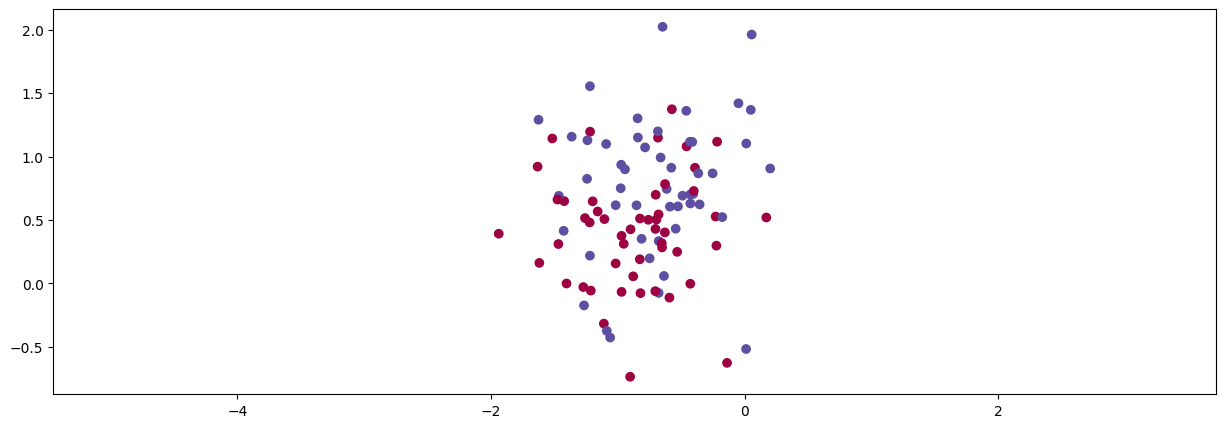

In [7]:
N = 1000

X, y = make_blobs(n_samples=N, n_features=50, centers=2,
                  cluster_std=3.0, random_state=seed)
y[y != 1] = -1

# Scale data and plot
X = scaler.fit_transform(X)

plt.scatter(X[:,0], X[:,1], c=y, cmap=my_cmap)
plt.axis('equal')
plt.show()

N_new=100
X_new, y_new = make_blobs(n_samples=N_new, n_features=50, centers=2,
                  cluster_std=3.0, random_state=seed+1)

# Transform new data
X_new = scaler.transform(X_new)

plt.scatter(X_new[:,0], X_new[:,1], c=y_new, cmap=my_cmap)
plt.axis('equal')
plt.show()

#### Hyperparameter `sigma`

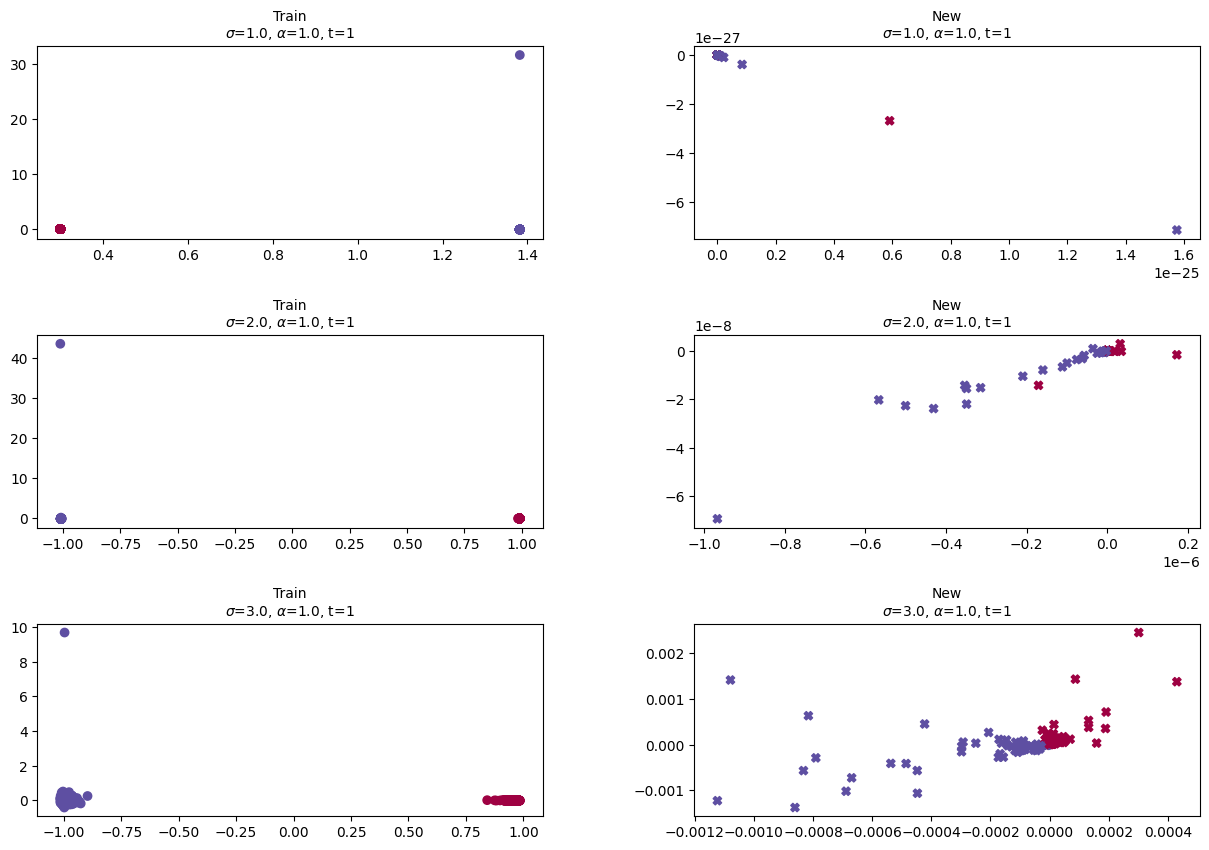

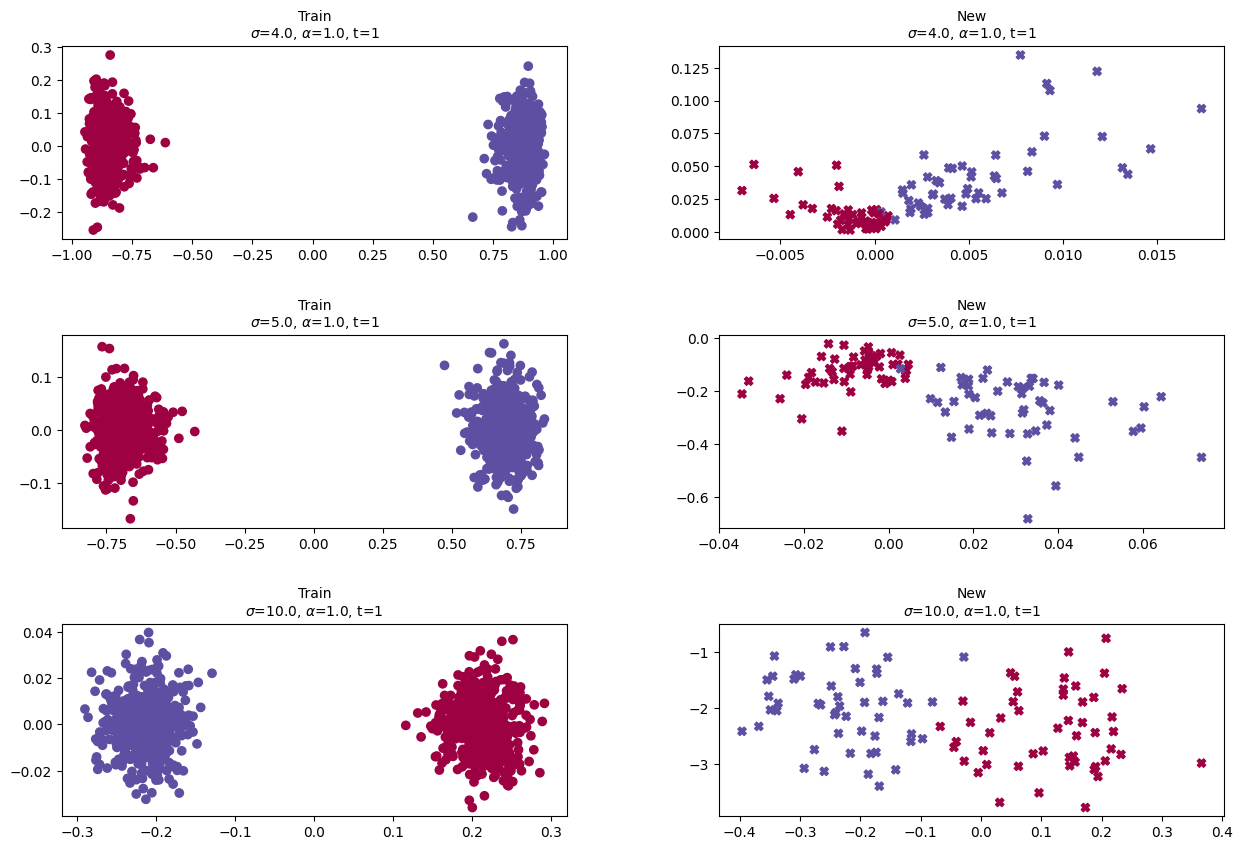

In [8]:
param_grid = {
    'sigma': [1.0, 2.0, 3.0, 4.0, 5.0, 10.0],
    'alpha': [1.0],
    'step': [1]
}

plot_diffusion_embeddings(X, y, X_new, y_new, param_grid)

#### Hyperparameter `alpha`

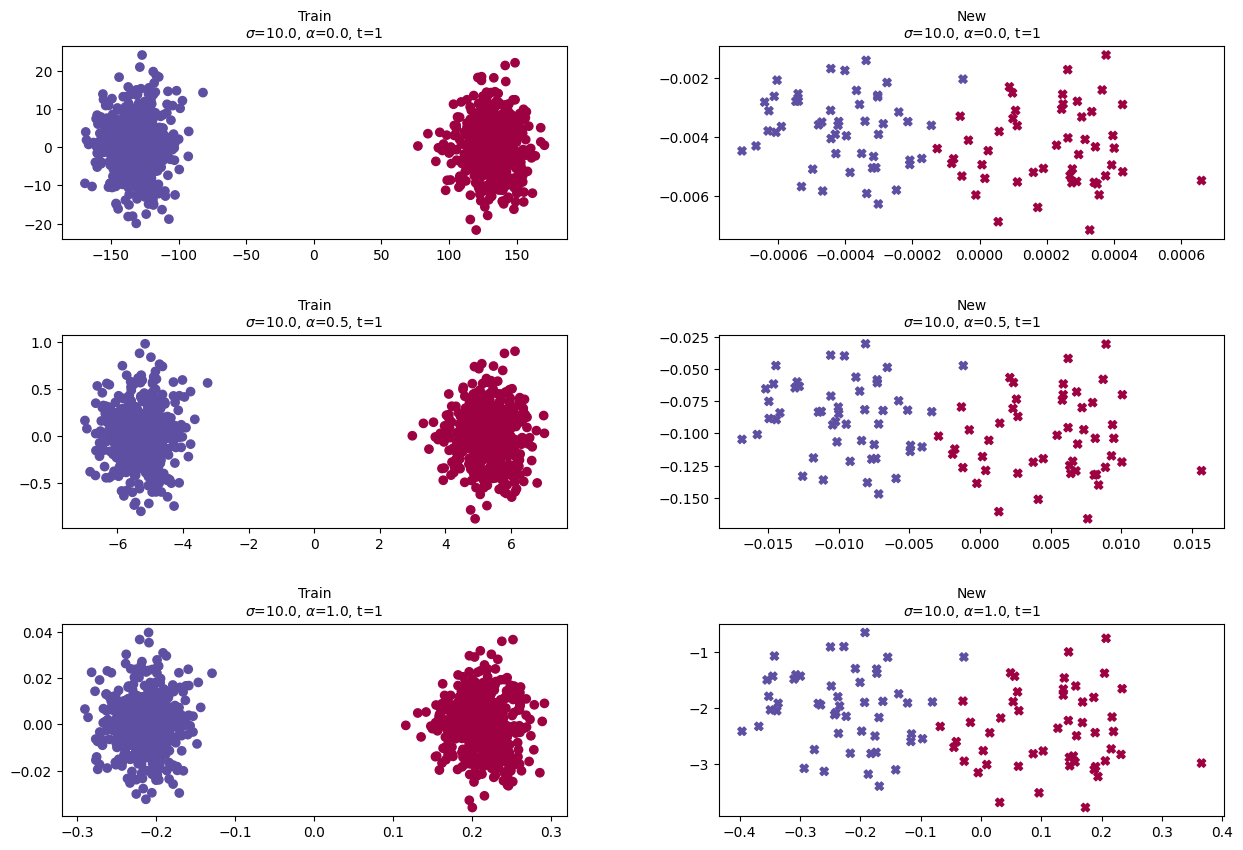

In [9]:
param_grid = {
    'sigma': [10.0],
    'alpha': [0.0, 0.5, 1.0],
    'step': [1]
}

plot_diffusion_embeddings(X, y, X_new, y_new, param_grid)

#### Hyperparameter `Step`

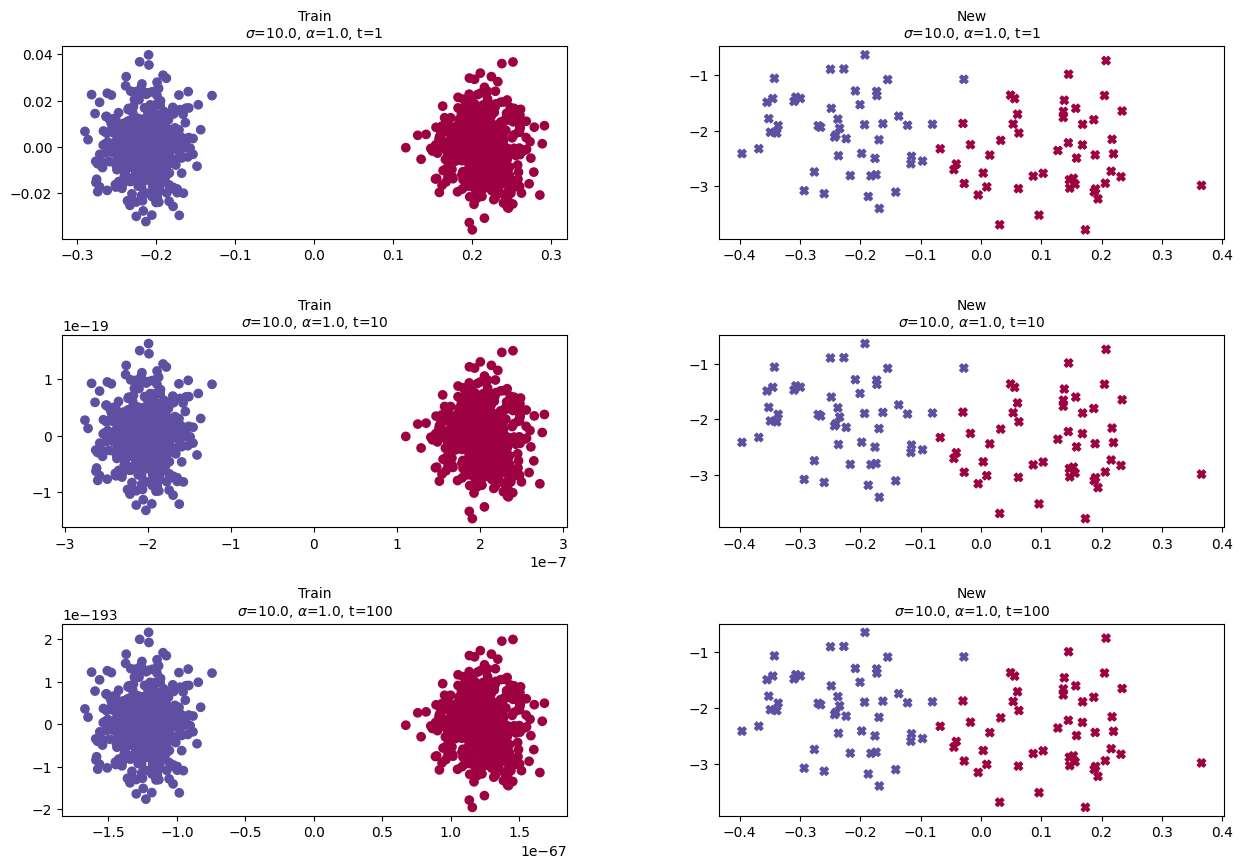

In [10]:
param_grid = {
    'sigma': [10.0],
    'alpha': [1.0],
    'step': [1, 10, 100]
}

plot_diffusion_embeddings(X, y, X_new, y_new, param_grid)

#### Parameter `N`

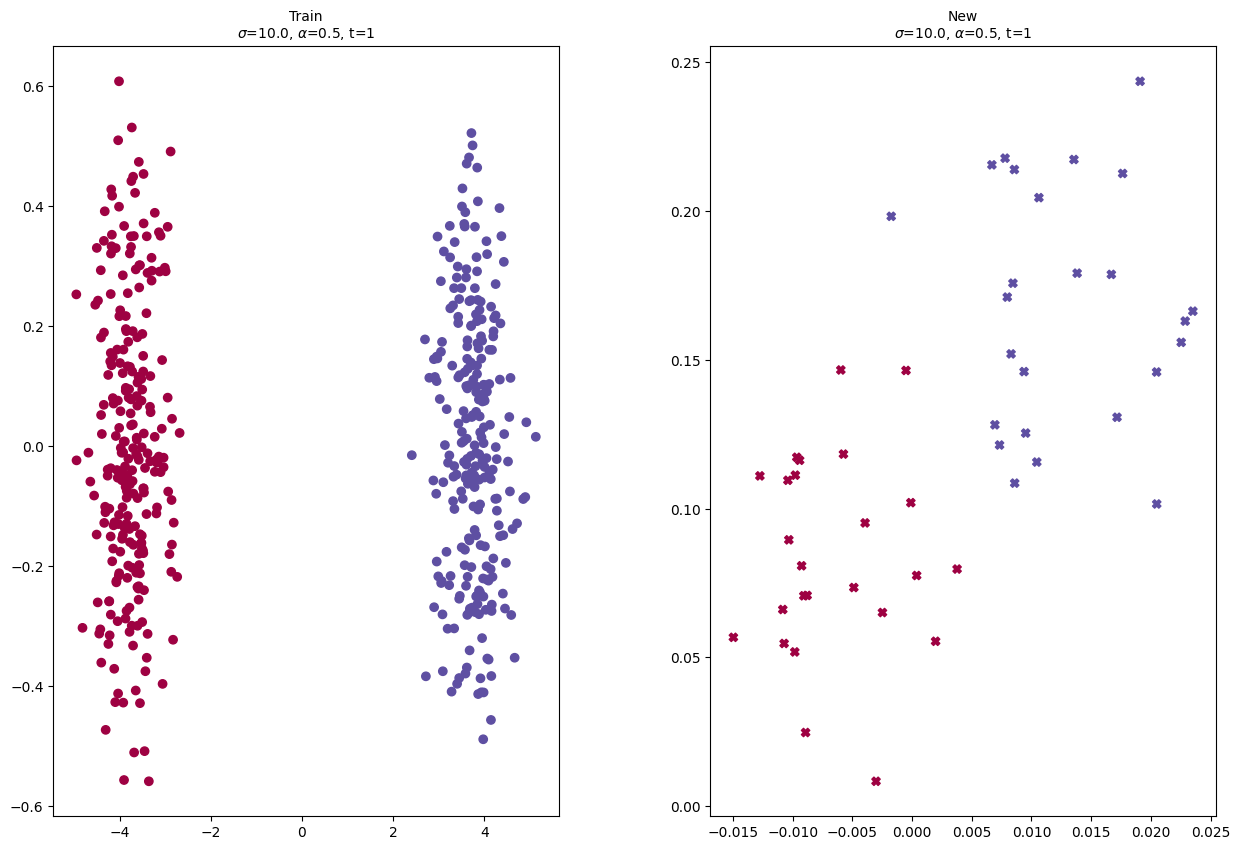

In [11]:
N = 500

X, y = make_blobs(n_samples=N, n_features=50, centers=2,
                  cluster_std=3.0, random_state=seed)
y[y != 1] = -1

# Scale data and plot
X = scaler.fit_transform(X)

N_new=50
X_new, y_new = make_blobs(n_samples=N_new, n_features=50, centers=2,
                  cluster_std=3.0, random_state=seed+1)

# Transform new data
X_new = scaler.transform(X_new)

param_grid = {
    'sigma': [10.0],
    'alpha': [0.5],
    'step': [1]
}

plot_diffusion_embeddings(X, y, X_new, y_new, param_grid)

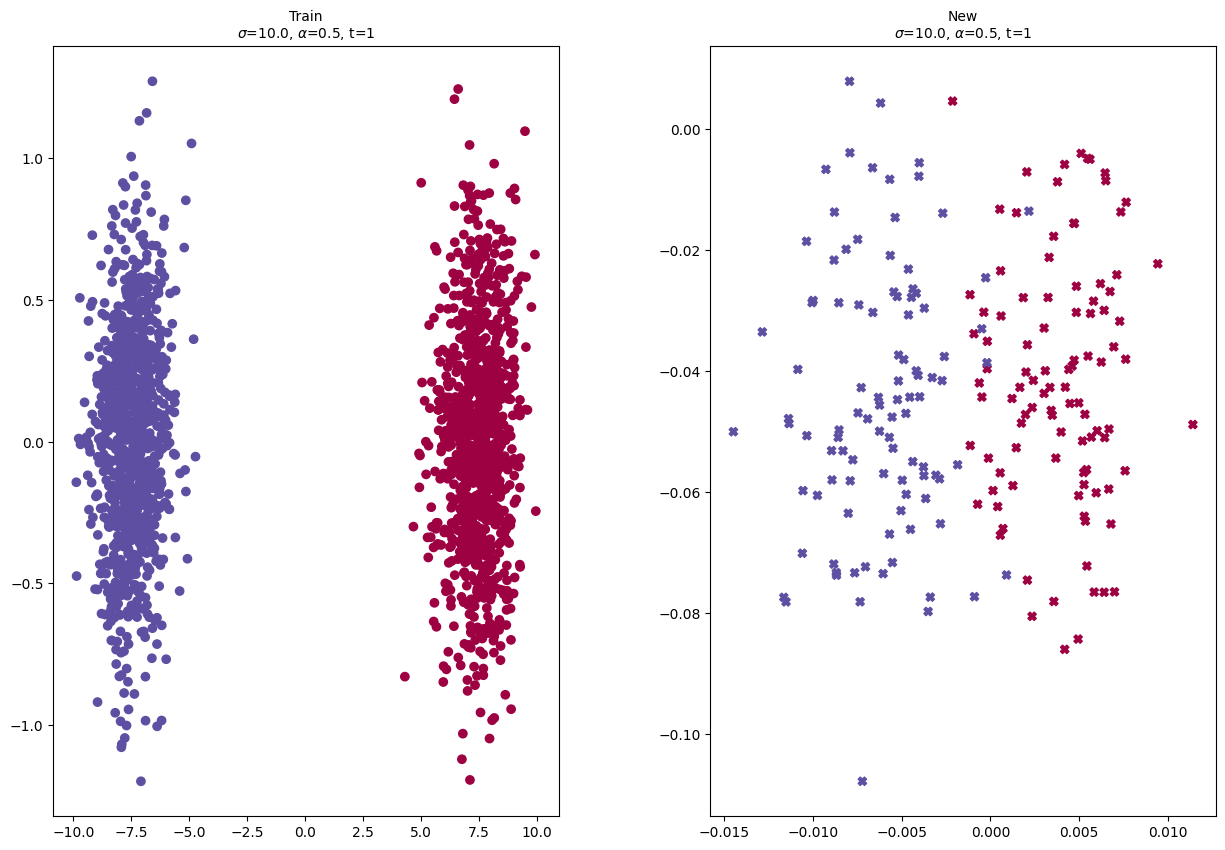

In [12]:
N = 2000

X, y = make_blobs(n_samples=N, n_features=50, centers=2,
                  cluster_std=3.0, random_state=seed)
y[y != 1] = -1

# Scale data and plot
X = scaler.fit_transform(X)


N_new=200
X_new, y_new = make_blobs(n_samples=N_new, n_features=50, centers=2,
                  cluster_std=3.0, random_state=seed+1)

# Transform new data
X_new = scaler.transform(X_new)


param_grid = {
    'sigma': [10.0],
    'alpha': [0.5],
    'step': [1]
}

plot_diffusion_embeddings(X, y, X_new, y_new, param_grid)

## Dataset 2: the swiss roll

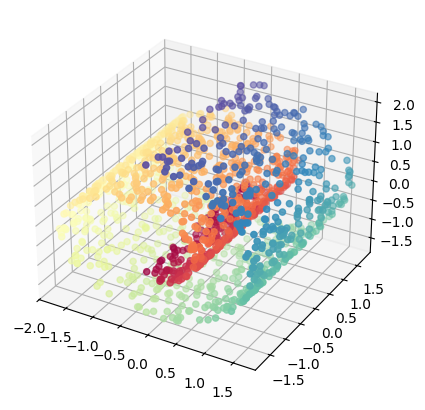

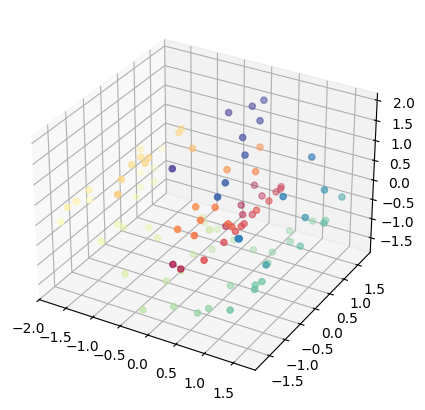

In [13]:
N=1500
X, color = make_swiss_roll(n_samples=N, random_state=seed)

# Scale data and plot
X = scaler.fit_transform(X)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=color, cmap=my_cmap)
plt.show()

N_new=100
X_new, color_new = make_swiss_roll(n_samples=N_new, random_state=seed+1)

# Transform new data
X_new = scaler.transform(X_new)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_new[:, 0], X_new[:, 1], X_new[:, 2], c=color_new, cmap=my_cmap)
plt.show()


#### Hyperparameter `sigma`

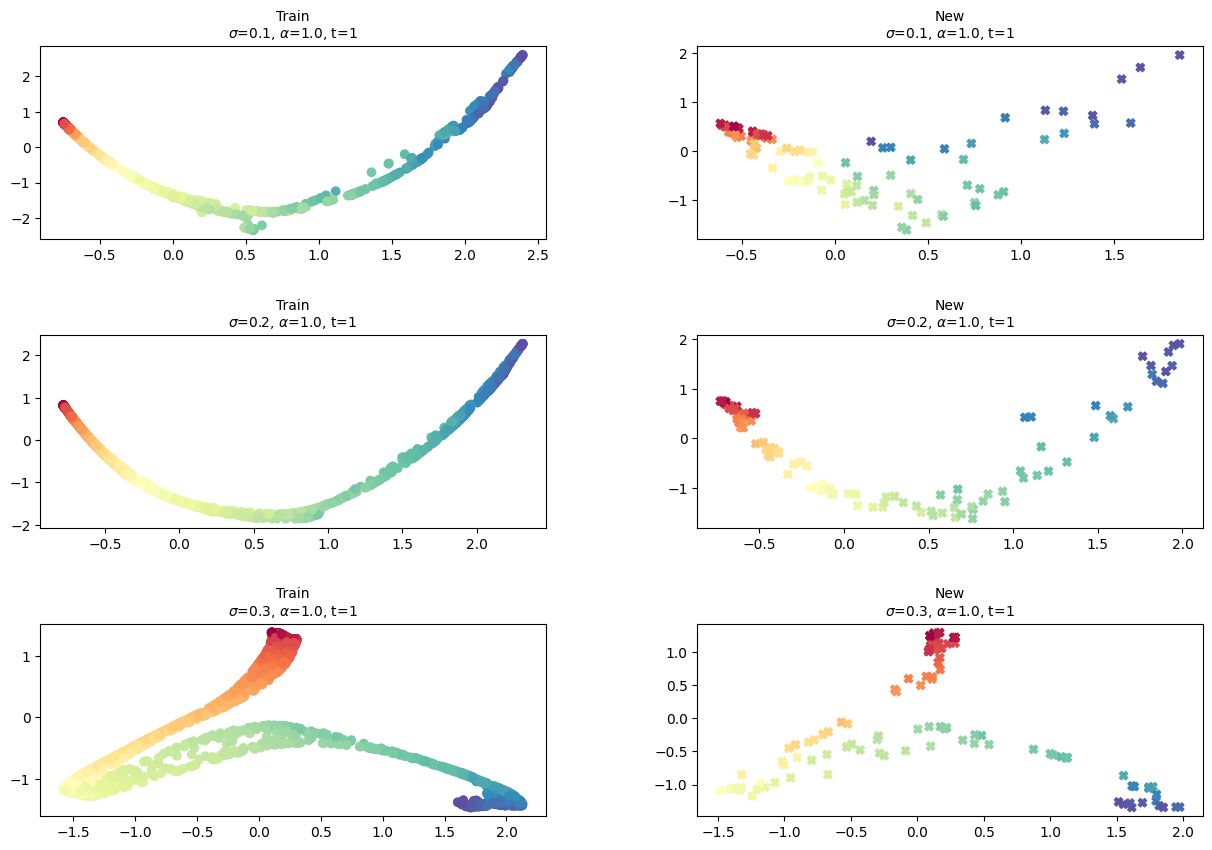

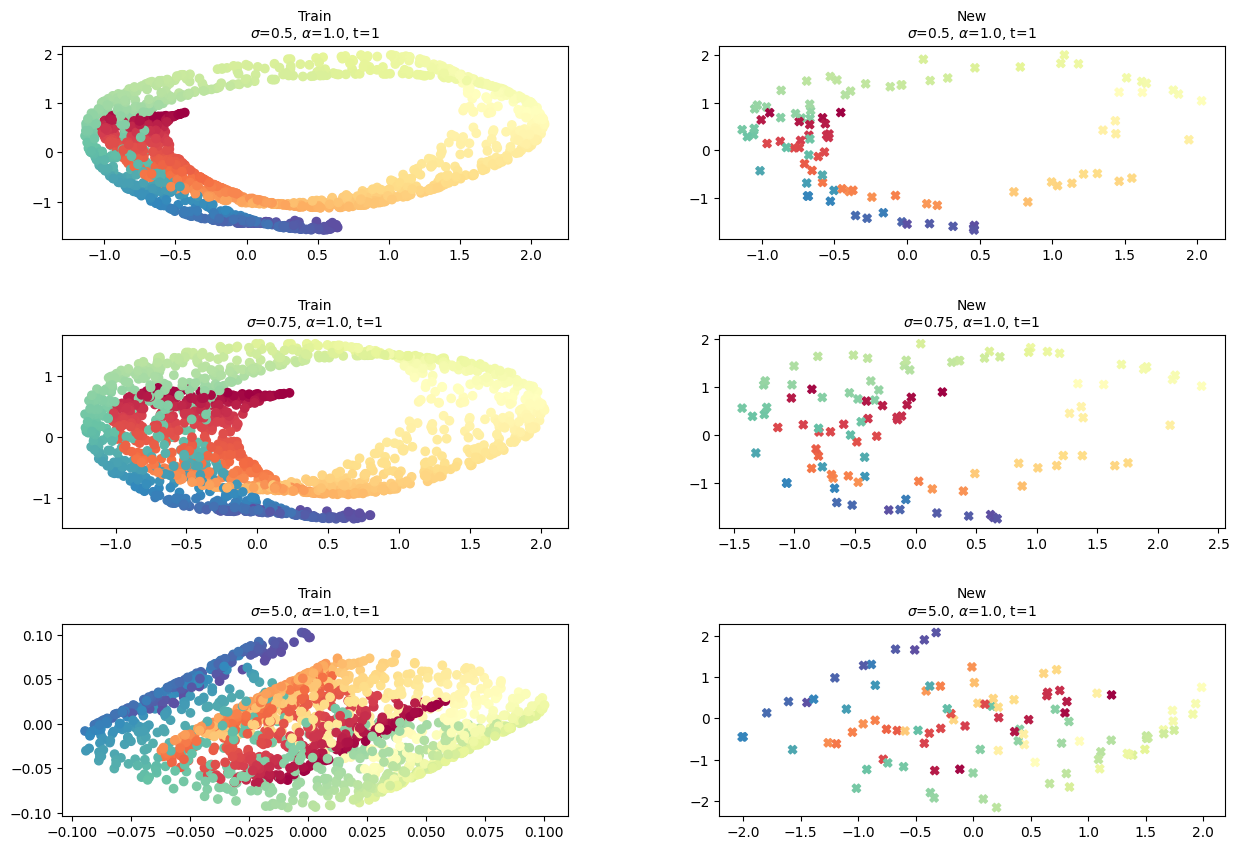

In [14]:
param_grid = {
    'sigma': [0.1, 0.2, 0.3, 0.5, 0.75, 5.0],
    'alpha': [1.0],
    'step': [1]
}

plot_diffusion_embeddings(X, color, X_new, color_new, param_grid)

#### Hyperparameter `alpha`

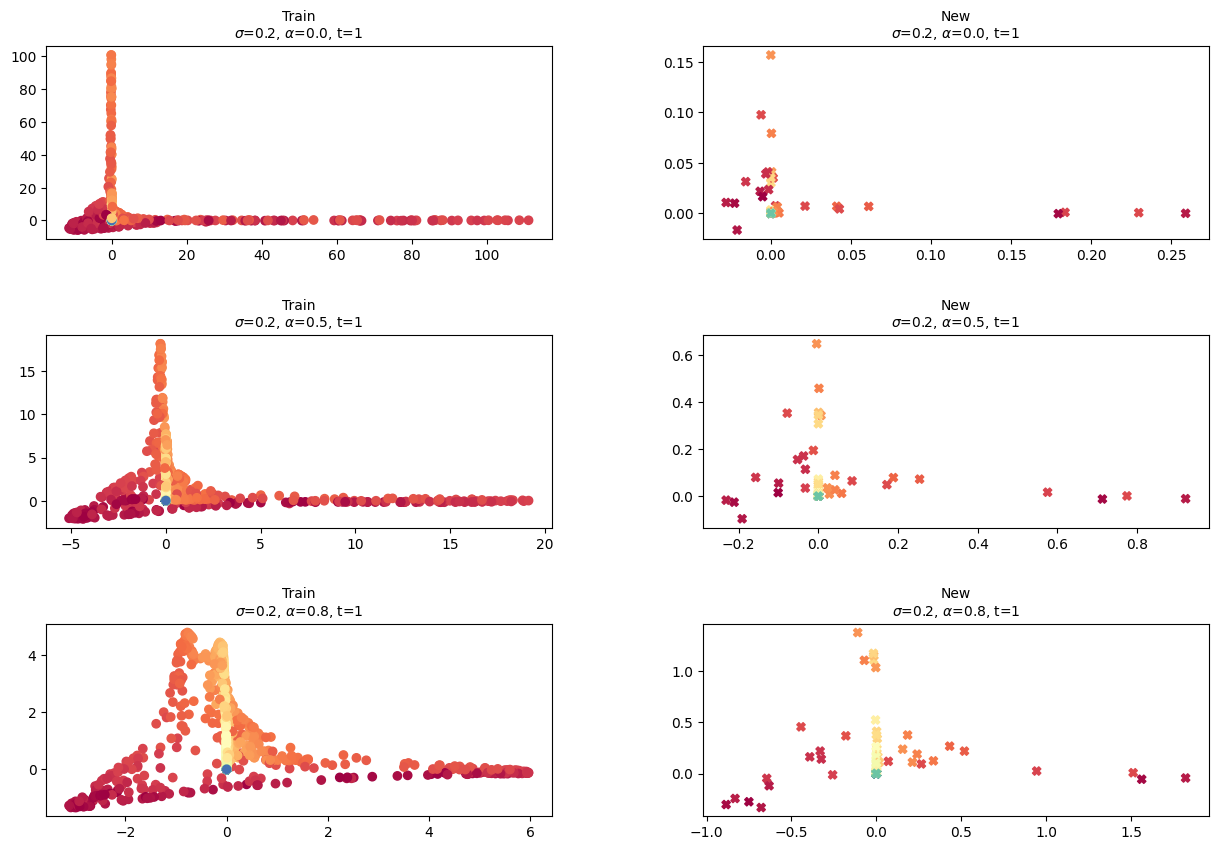

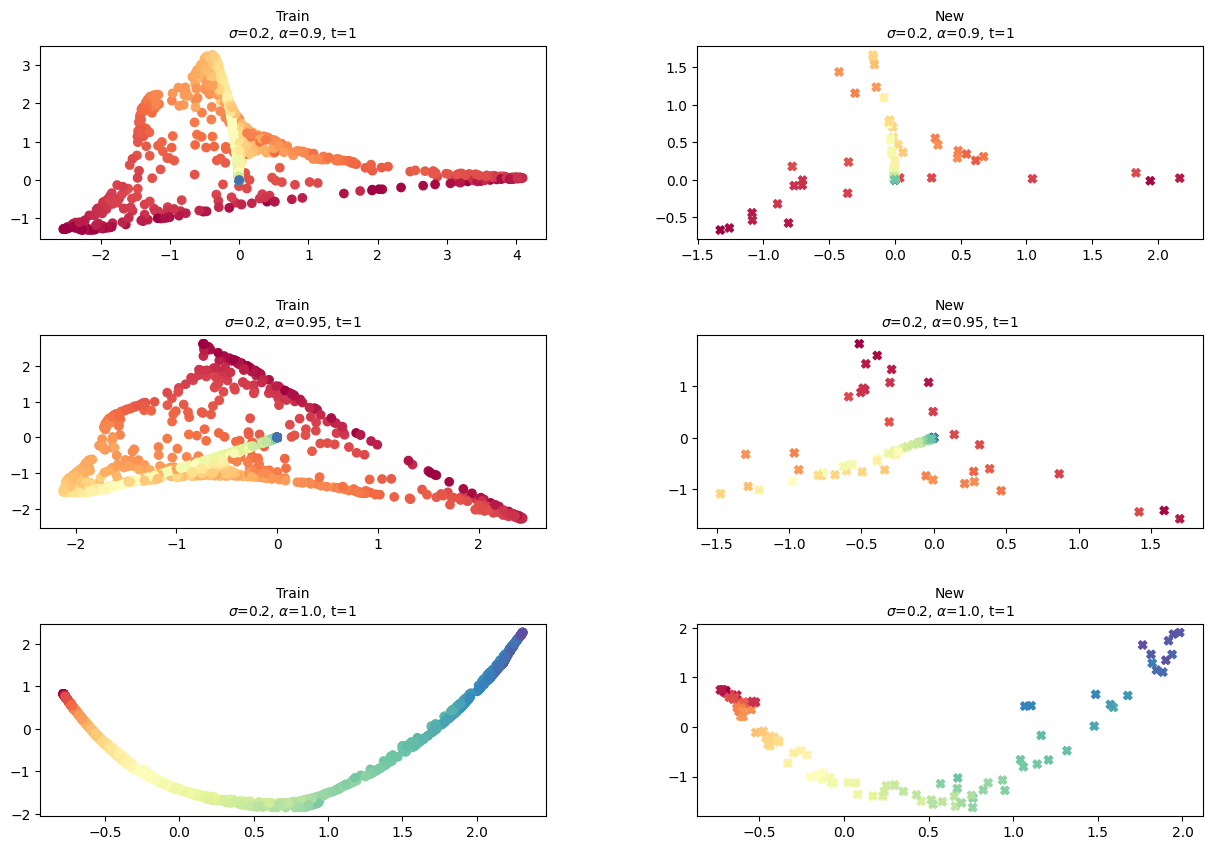

In [15]:
param_grid = {
    'sigma': [0.2],
    'alpha': [0.0, 0.5, 0.8, 0.9, 0.95, 1.0],
    'step': [1]
}

plot_diffusion_embeddings(X, color, X_new, color_new, param_grid)

#### Hyperparameter `step`

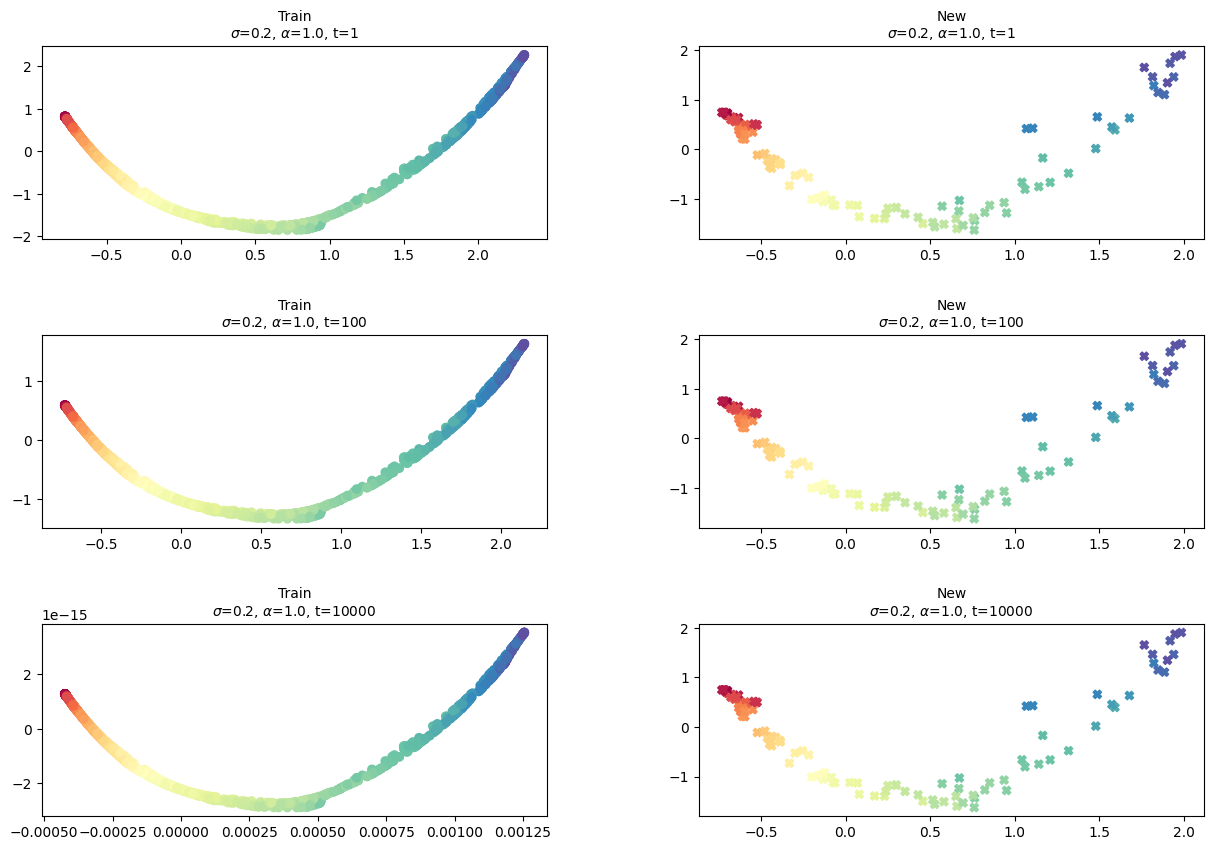

In [16]:
param_grid = {
    'sigma': [0.2],
    'alpha': [1.0],
    'step': [1, 100, 10000]
}

plot_diffusion_embeddings(X, color, X_new, color_new, param_grid)

#### Parameter `N`

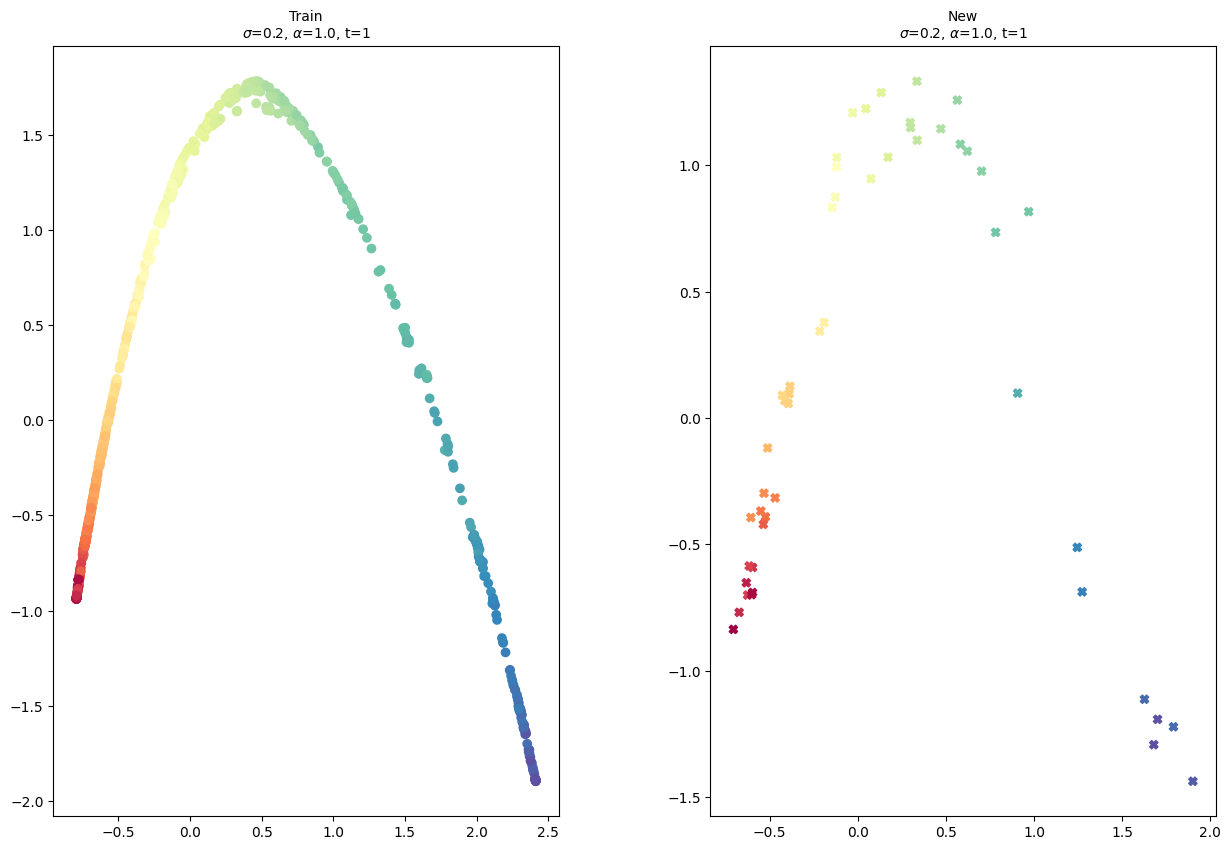

In [17]:
N=750
X, color = make_swiss_roll(n_samples=N, random_state=seed)

# Scale data and plot
X = scaler.fit_transform(X)

N_new=50
X_new, color_new = make_swiss_roll(n_samples=N_new, random_state=seed+1)

# Transform new data
X_new = scaler.transform(X_new)

param_grid = {
    'sigma': [0.2],
    'alpha': [1.0],
    'step': [1]
}

plot_diffusion_embeddings(X, color, X_new, color_new, param_grid)

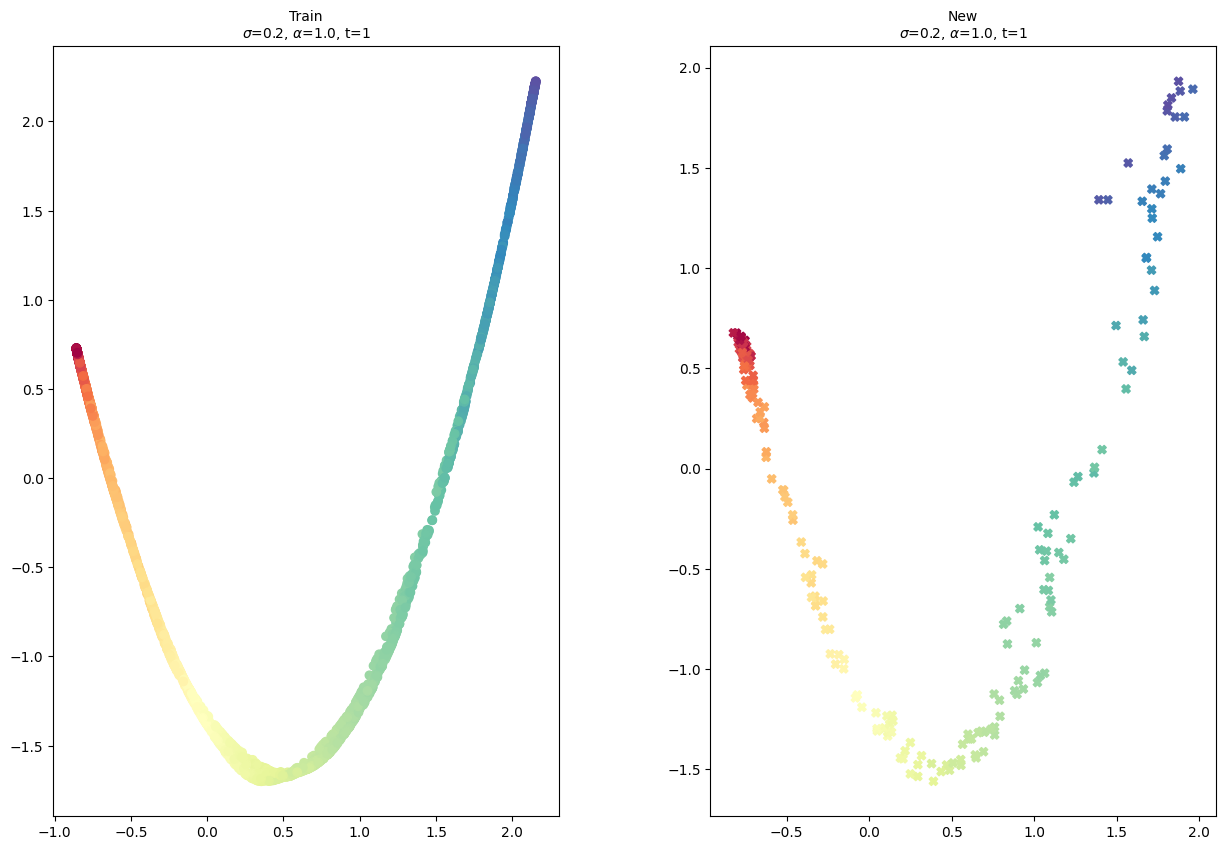

In [18]:
N=3000
X, color = make_swiss_roll(n_samples=N, random_state=seed)

# Scale data and plot
X = scaler.fit_transform(X)

N_new=200
X_new, color_new = make_swiss_roll(n_samples=N_new, random_state=seed+1)

# Transform new data
X_new = scaler.transform(X_new)

param_grid = {
    'sigma': [0.2],
    'alpha': [1.0],
    'step': [1]
}

plot_diffusion_embeddings(X, color, X_new, color_new, param_grid)

## Dataset 3: the S curve

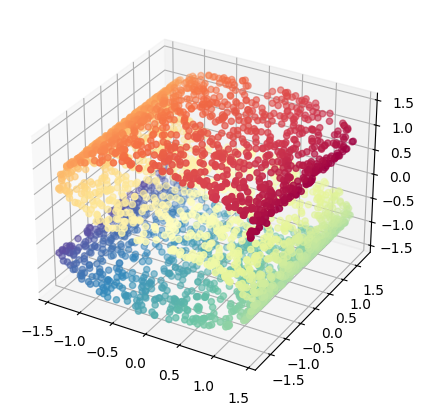

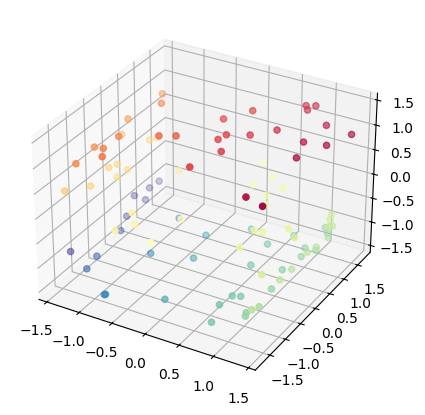

In [19]:
N = 3000
X, color = make_s_curve(N, random_state=seed)

# Scale data and plot
X = scaler.fit_transform(X)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=color, cmap=my_cmap)
plt.show()

N_new = 100
X_new, color_new = make_s_curve(N_new, random_state=seed+1)

# Transform new data
X_new = scaler.transform(X_new)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_new[:, 0], X_new[:, 1], X_new[:, 2], c=color_new, cmap=my_cmap)
plt.show()

#### Hyperparameter `sigma`

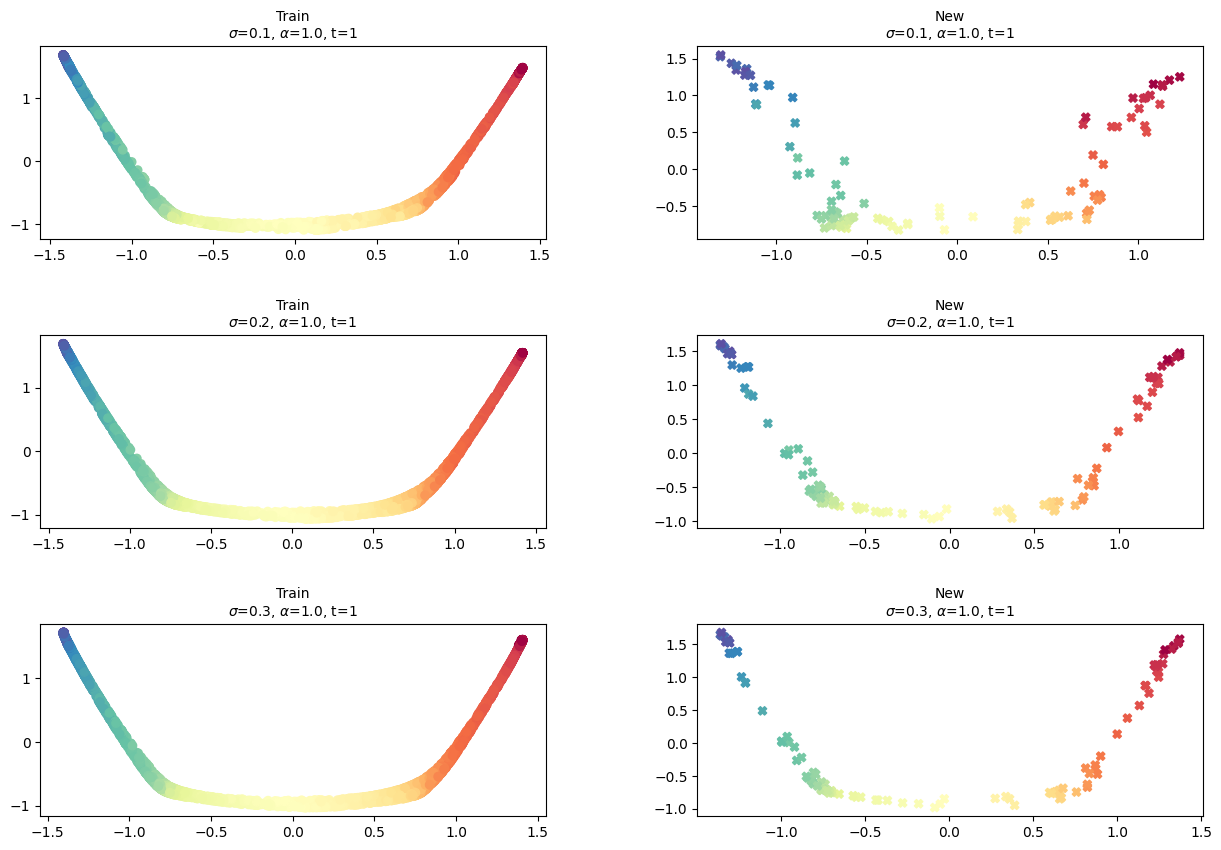

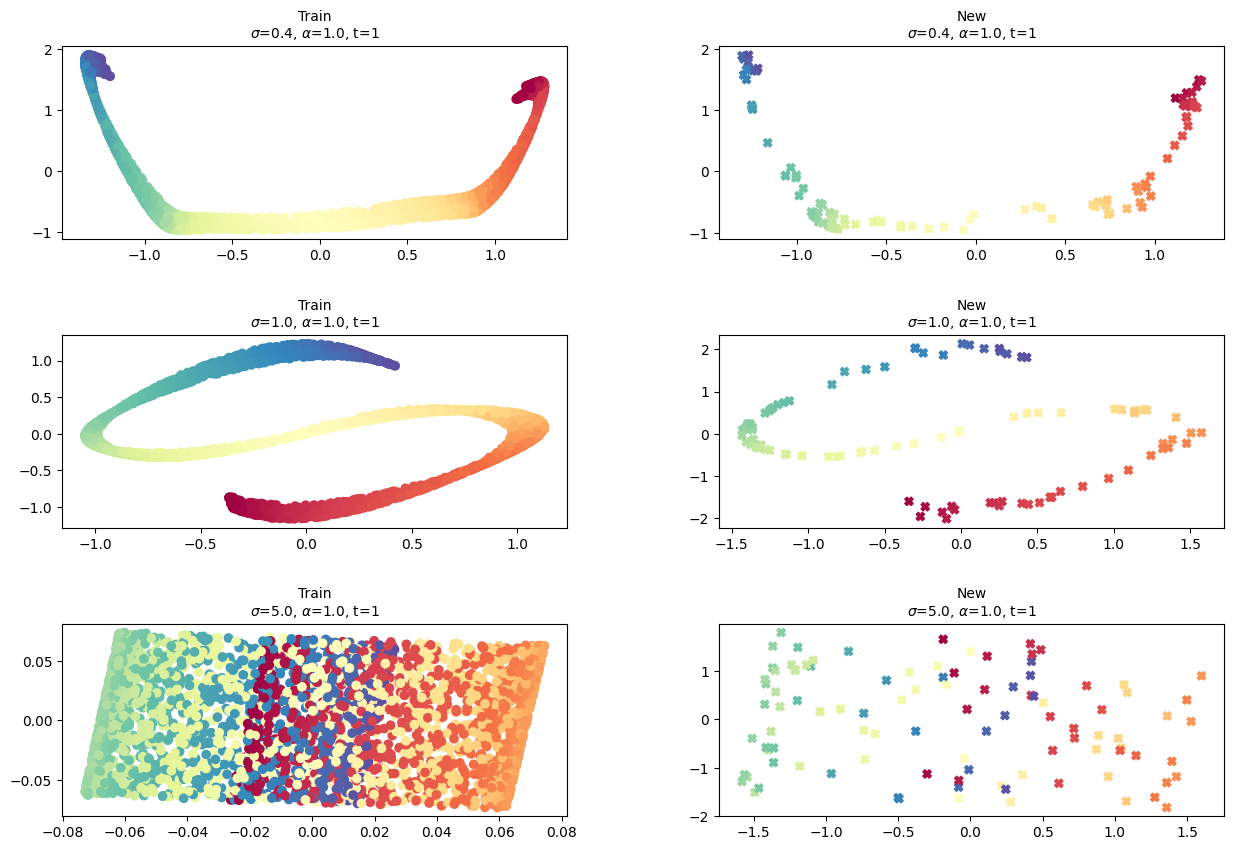

In [20]:
param_grid = {
    'sigma': [0.1, 0.2, 0.3, 0.4, 1.0, 5.0],
    'alpha': [1.0],
    'step': [1]
}

plot_diffusion_embeddings(X, color, X_new, color_new, param_grid)

#### Hyperparameter `alpha`

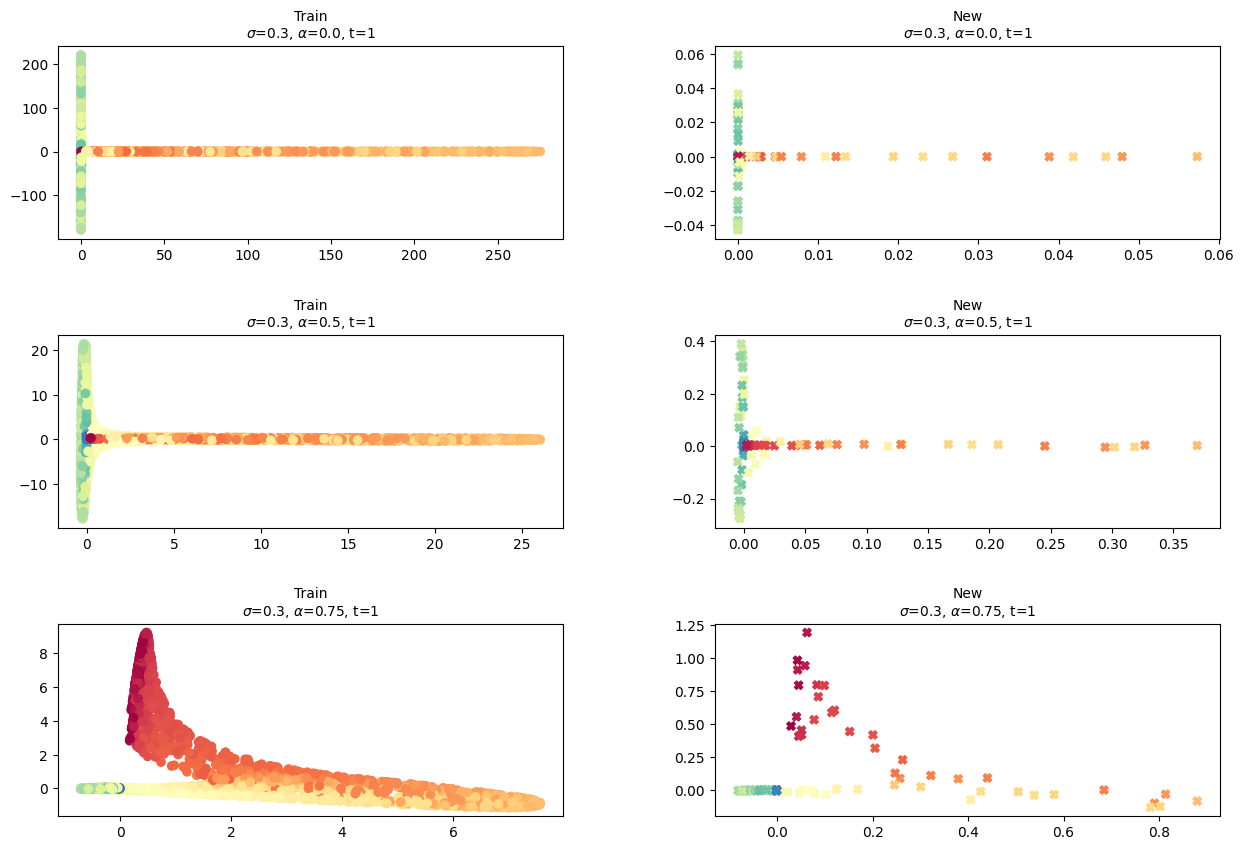

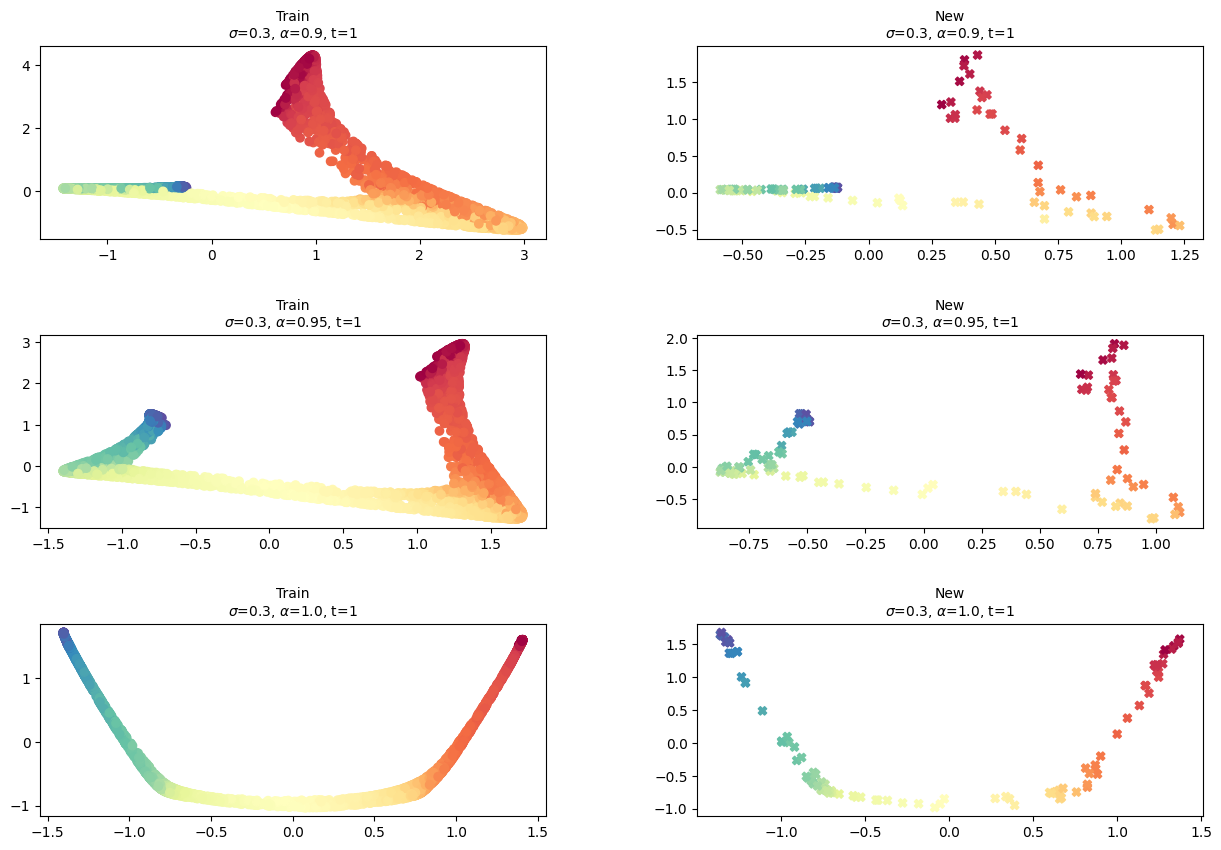

In [21]:
param_grid = {
    'sigma': [0.3],
    'alpha': [0.0, 0.50, 0.75, 0.9, 0.95, 1.0],
    'step': [1]
}

plot_diffusion_embeddings(X, color, X_new, color_new, param_grid)

#### Hyperparameter `step`

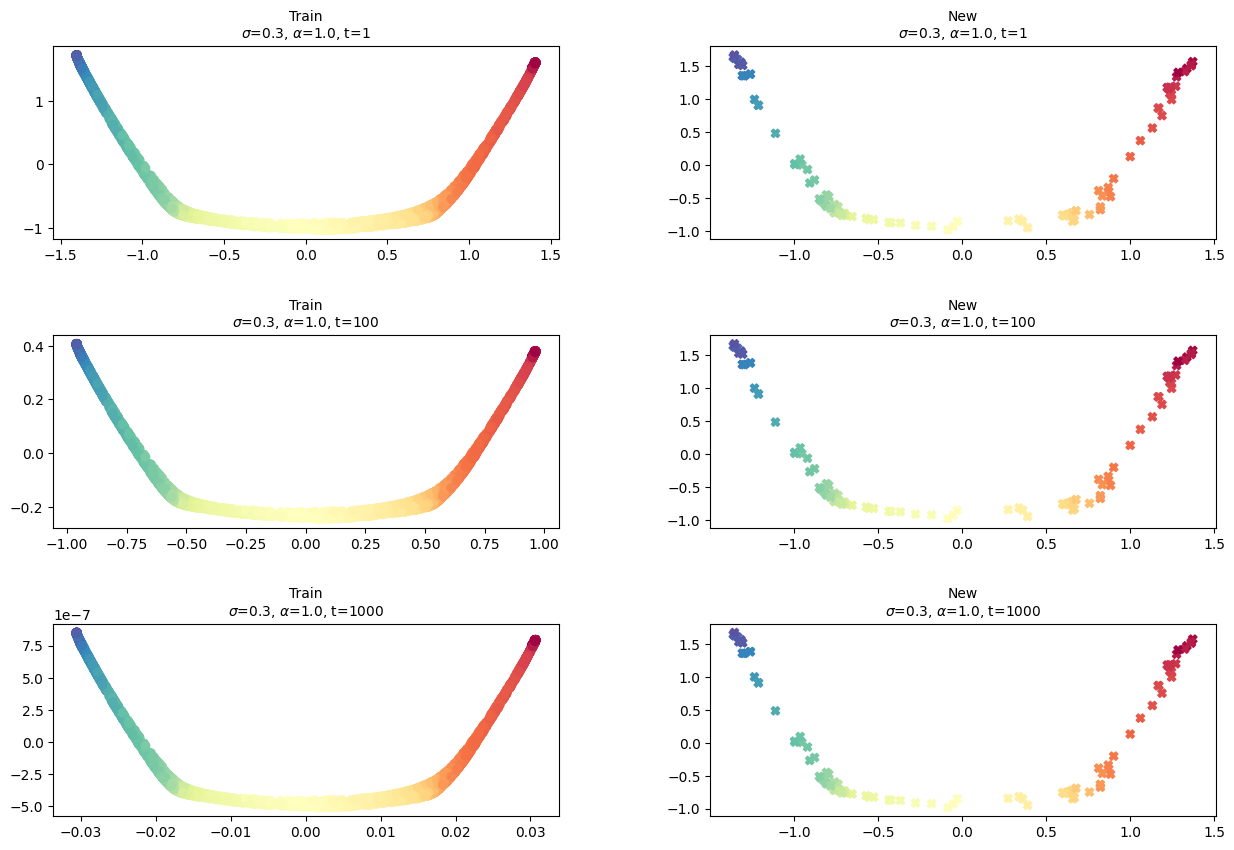

In [22]:
param_grid = {
    'sigma': [0.3],
    'alpha': [1.0],
    'step': [1, 100, 1000]
}

plot_diffusion_embeddings(X, color, X_new, color_new, param_grid)

#### Parameter `N`

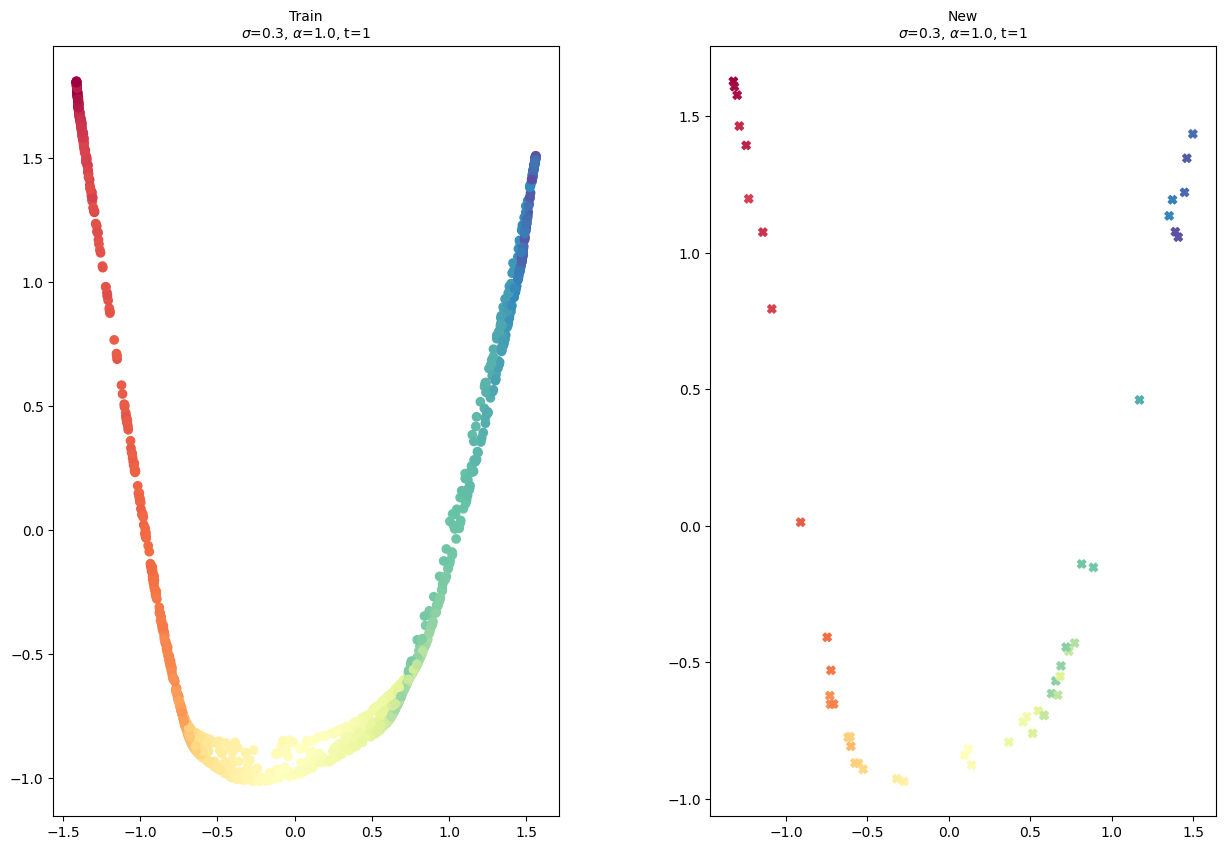

In [23]:
N = 1500
X, color = make_s_curve(N, random_state=seed)

# Scale data and plot
X = scaler.fit_transform(X)

N_new = 50
X_new, color_new = make_s_curve(N_new, random_state=seed+1)

# Transform new data
X_new = scaler.transform(X_new)

param_grid = {
    'sigma': [0.3],
    'alpha': [1.0],
    'step': [1]
}

plot_diffusion_embeddings(X, color, X_new, color_new, param_grid)

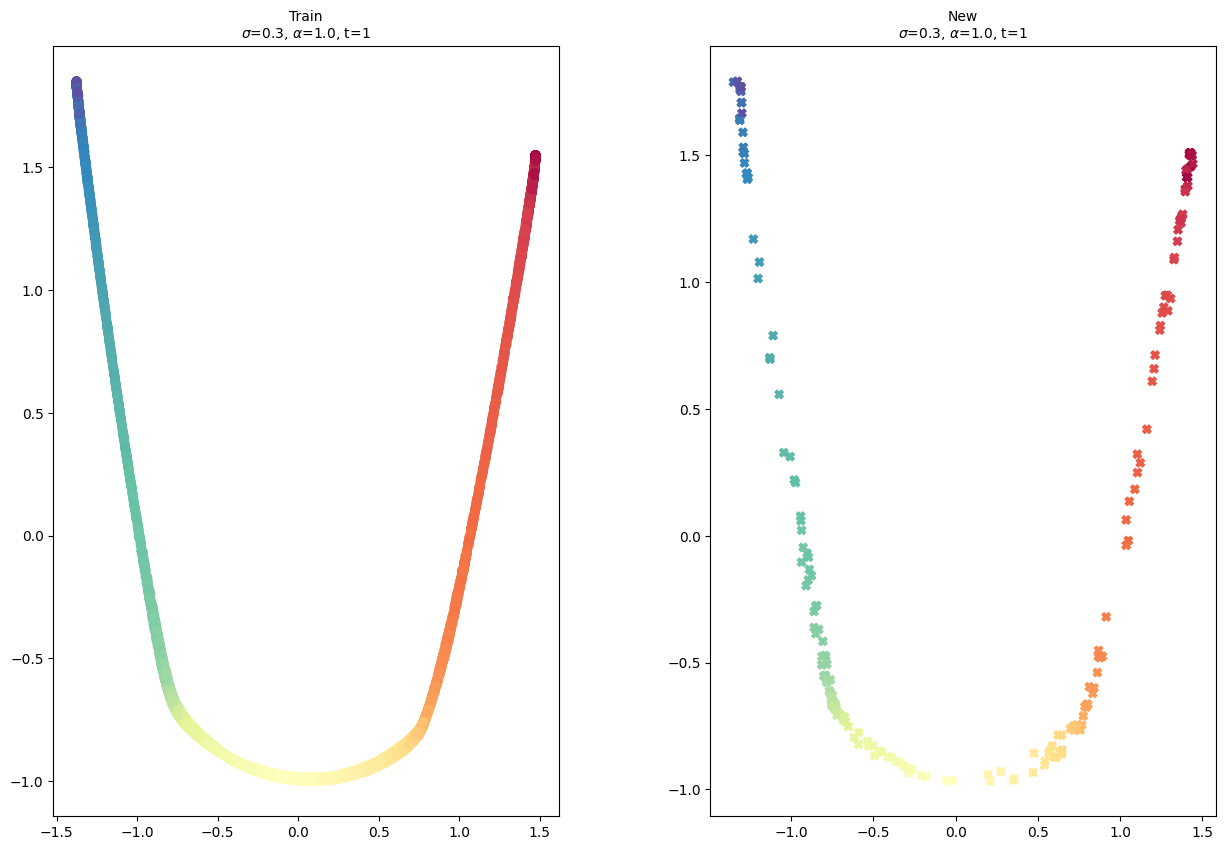

In [24]:
N = 6000
X, color = make_s_curve(N, random_state=seed)

# Scale data and plot
X = scaler.fit_transform(X)

N_new = 200
X_new, color_new = make_s_curve(N_new, random_state=seed+1)

# Transform new data
X_new = scaler.transform(X_new)

param_grid = {
    'sigma': [0.3],
    'alpha': [1.0],
    'step': [1]
}

plot_diffusion_embeddings(X, color, X_new, color_new, param_grid)

<div class="qst">

1. Do you consider that the embedding obtained is good for the previous datasets? Is it the expected one? Why?
    
    
2. How sensible is the method to its hyper-parameters? Specify the best values that you have found and the technique employed for it.
    * Check how much influence has the sample density (you can vary N for each dataset).
    * Check what happens if the number of steps `steps` grows.
   
    
3. In your opinion, which is the main advantage and disadvantage of this method?
    
</div>

**Answer**:

1. **Do you consider that the embedding obtained is good for the previous datasets? Is it the expected one? Why?**

    The desired embedding for the *blobs* dataset is one which separates the classes completely whereas for the *S* and the *Swiss roll* datasets, the desired embedding is a rectangle, a carpet of the datapoints that extends the shapes of the roll and the S completely.

    Therefore, the embeddings obtained for the *blobs* is quite good as there is a clear linear separation of the points of the two classes, both for the trained points and the new test points. We can then conclude that the embedding obtained for this dataset is quite good and is similar as the one we would expect.

    However, for the *S* and the *Swiss roll* datasets, the desired embedding is not obtained. We get an embedding which is good but not the best than can be obtained. In both datasets, the embedding corresponds to a line separating the dots by color but we cannot get the width dimension that would correspond to a carpet. Thus, although the embeddings obtained separate the data, they are not the expected one.

2. **How sensible is the method to its hyper-parameters? Specify the best values that you have found and the technique employed for it.**

    As we have seen in the multiples plots performed, the variation of the hyperparameters has a huge influence in the embedding performed. As there is no performance metric to measure how good the embedding is, makes the task of finding the best hyperparameters quite ardous as a exhaustive search must be performed. Thus, the technique used for the finding of the hyperparameters is a trial-error technique and plotting the result of the combination of the hyperparameters to find the ones that give us the best separation of the points.

    The best values for the hyperparameters for each dataset is:
    1. *Blobs*: `sigma = 10.0`, `alpha` any value, `step` any value
    2. *Swiss roll*: `sigma = 0.2`, `alpha = 1.0`, `step` any value
    3. *S*: `sigma = 0.3`, `alpha = 1.0`, `step` any value

    * **Check how much influence has the sample density (you can vary N for each dataset).**

        For the *blobs* dataset, the variation of the sample density has little impact on the results. The main difference is that, as `N` increases, the separation of the points for the new data becomes worse, mainly because there are a lot of points deep in the region of the opposite class points so they are more difficult to separate. However, this separation is still very visible and that is the reason we state that there is little influence of the density of points.

        For the *Swiss roll* and the *S* datasets, the variation of `N` has more impact on the resulting embedding. It is clear that, as `N` increases the embedding becomes smoother and the results improve. We still cannot obtained the desired behavior but the results are better for larger values of `N`.
    
    * **Check what happens if the number of steps `steps` grows.**

        As it was expected, increasing the number of steps $T$ has the effect of making the distance between the points of the embedding smaller. This is because when computing the eigendecomposition of $P$ we get:
        $$
        p_{ij} = \sum_{l \leq 0} \lambda_l^T(\psi_l)_i (\phi_l)_j
        $$
        and, as $\lambda_l(\psi_l) < 1$, as $T$ increases the eigenvalues become smaller and thus, the embedding scale is reduced.

        This behavior is what we can see. The embedding of the points is not affected when changing the `step` hyperparameter but the scale of the axes is clearly decreased as the step increases. This is observed in all datasets.

3. **In your opinion, which is the main advantage and disadvantage of this method?**

    The main advatages of this method are that we are able to unroll the datapoints of complex manifolds into an embedding with a number of dimensions that can be changed. This makes the method very flexible and also allows to capture the geometry of the datapoints while generating the embeddings.

    The main disadvantages is that there is no metric to determine the quality of the embedding and the hyperparameter sensitility of this method makes the search of the right model very costly. This combination is the main drawback of the methods. Furthermore, the eigendecomposition of the affinity matrix makes it a quite computationally costly method.